# Report on Judge Experience within American Parliamentary Debate Association (APDA) Rounds

In this report, I hope to address concerns debaters have surrounding the Judging Experience within collegiate APDA rounds. Many debaters worry about the experience level of judges at each tournament they attend; typically, concerns are that if the judge has not debated much themselves, it might result in an unwarranted outcome of the round. In order to address these concerns, I hope to investigate the experience of Judges at each Host School's tournament to see if such discrepancies do exist and investigate causes.

In [241]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Clean data set on APDA rounds spanning from Fall 2019 to Spring 2026
df_rounds = pd.read_csv("Data_Curation_Data/Rounds_Data.csv")
# Clean data set on debaters registered with an APDA school
df_roster = pd.read_csv("All_Debaters.csv")

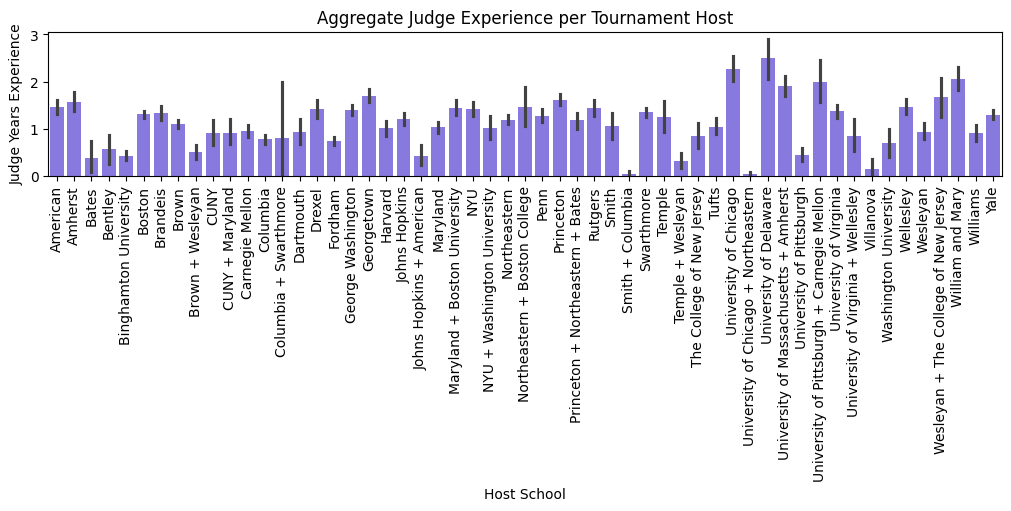

In [242]:
df_rounds["Judge Years Experience"] = df_rounds["Judge Years Experience"].clip(lower=0)
fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")

ax = sns.barplot(df_rounds, x="Tournament", y="Judge Years Experience", orient='v', color="mediumslateblue", order=sorted(df_rounds["Tournament"].unique()))
ax.set_title("Aggregate Judge Experience per Tournament Host")
ax.set_xlabel("Host School")
ax.tick_params(axis="x", rotation=90)

plt.show()

Many "Host Schools" in the above graph are combined efforts such as "CUNY + Maryland" this was a singular tournament, as opposed the other Host schools which host (normally) a biannual tournament. These combined tournament hosts only occured during the COVID-19 pandemic online debate days. As the online format of tournament is not relevant for furture in-person tournament decision making, I will filter out these one time occurence tournaments in order to visualize the data better. 

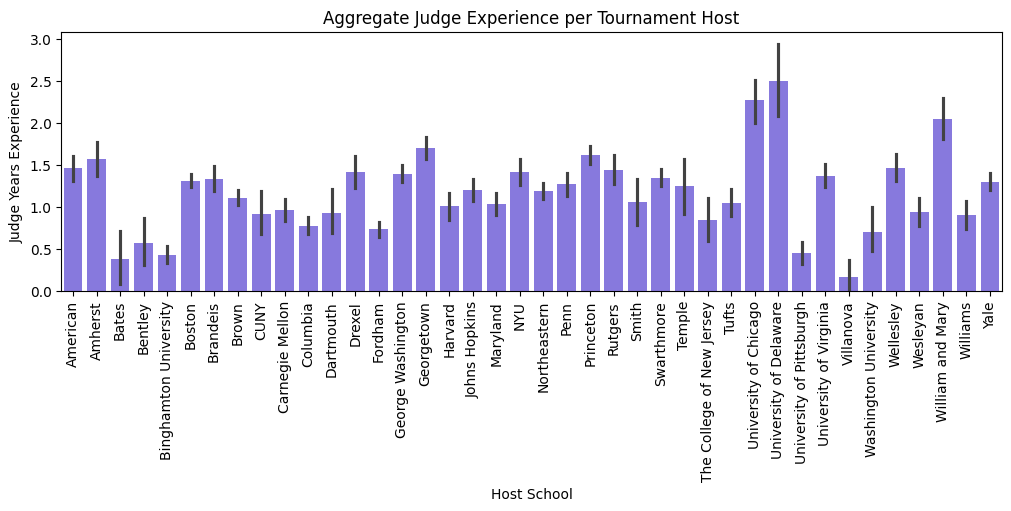

In [243]:
# Drop combined (online) tournaments that occurred during covid and had higher percentage of alumni judging
combined_tournaments_to_drop = ["Columbia + Swarthmore", "Princeton + Northeastern + Bates", "Johns Hopkins + American",
                                "Maryland + Boston University", "CUNY + Maryland", "NYU + Washington University",
                                "Brown + Wesleyan", "University of Massachusetts + Amherst", "Maryland + Boston College",
                                "Wesleyan + The College of New Jersey", "Temple + Wesleyan", "Northeastern + Boston College", 
                                "University of Virginia + Wellesley", "Smith + Columbia", "Brown + Wesleyan", 
                                "University of Chicago + Northeastern", "University of Pittsburgh + Carnegie Mellon"]
df_rounds_no_covid = df_rounds[~df_rounds["Tournament"].isin(combined_tournaments_to_drop)]

fig, ax = plt.subplots(figsize=(10, 5), layout="constrained")

ax = sns.barplot(df_rounds_no_covid, x="Tournament", y="Judge Years Experience", orient='v', color="mediumslateblue", order=sorted(df_rounds_no_covid["Tournament"].unique()))
ax.set_title("Aggregate Judge Experience per Tournament Host")
ax.set_xlabel("Host School")
ax.tick_params(axis="x", rotation=90)

plt.show()

From this graph we can clearly see there are large discrepancies in the judging experience of judges by host school. In the hopes of identifying one potential contributing factor, the following graph will overlay the size of each host school's roster of debaters.

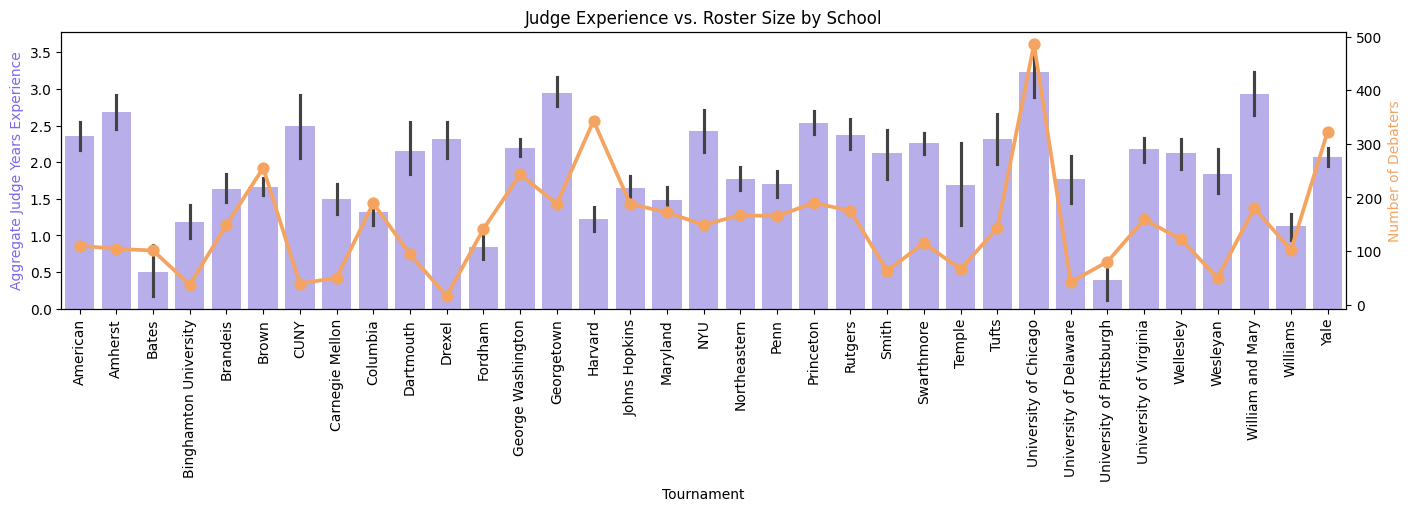

In [244]:
fig, ax1 = plt.subplots(figsize=(14, 5), layout="constrained")
sns.barplot(data=judge_subset, x="Tournament", y="Judge Years Experience",
            color="mediumslateblue", order=school_order, ax=ax1, alpha=0.6)
ax1.set_ylabel("Aggregate Judge Years Experience", color="mediumslateblue")

ax2 = ax1.twinx()
sns.pointplot(data=roster_subset, x="School", y=[1]*len(roster_subset),
              order=school_order, ax=ax2, color="sandybrown", estimator=len)
ax2.set_ylabel("Number of Debaters", color="sandybrown")

ax1.tick_params(axis="x", rotation=90)
plt.title("Judge Experience vs. Roster Size by School")
plt.show()

Here we can see some of the worst offenders in judge experience, such as Bates, Fordham, and University of Pittsburgh, do also have low roster numbers. Before, concluding anything, however, lets run a statistical analysis to test the trueness of this potential correlation.

In [245]:
judge_avg = (
    judge_subset.groupby("Tournament")["Judge Years Experience"]
    .mean()
    .rename("Avg Judge Experience")
)

roster_count = (
    roster_subset.groupby("School")
    .size()
    .rename("Roster Count")
)

corr_df = pd.concat([judge_avg, roster_count], axis=1).dropna()

In [246]:
pearson_r, pearson_p = stats.pearsonr(corr_df["Avg Judge Experience"], corr_df["Roster Count"])
spearman_r, spearman_p = stats.spearmanr(corr_df["Avg Judge Experience"], corr_df["Roster Count"])

print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3f}")

Pearson r = 0.259, p = 0.133
Spearman r = 0.178, p = 0.305


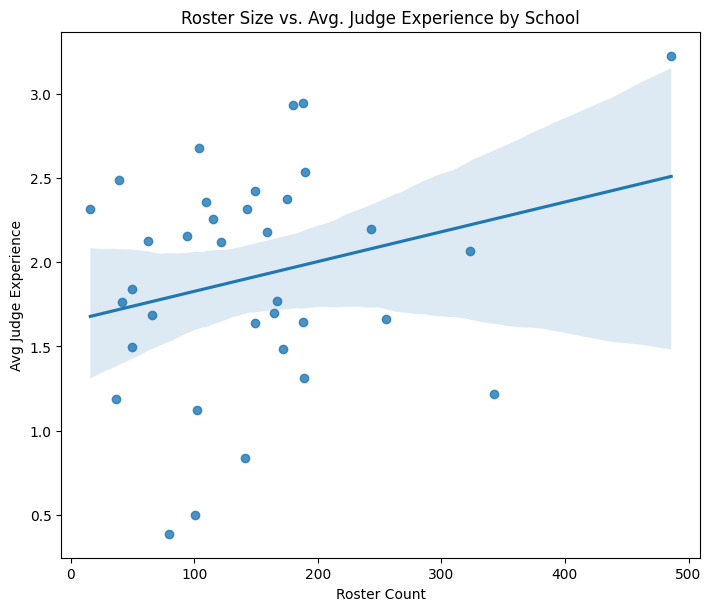

In [247]:
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
sns.regplot(data=corr_df, x="Roster Count", y="Avg Judge Experience", ax=ax)
ax.set_title("Roster Size vs. Avg. Judge Experience by School")
plt.show()

From the above tests, Pearson and Spearman, and keeping in mind our sample size of only 35 schools (n=35), we can conclude that we cannot reject the null hypothesis that there is no leanear (Pearson) or monotonic (Spearman) relationship between roster size and average judge experience. This does not prove roster size and judge experience are unrelated, however, with this sample size we do not have strong enough evidence to say they are related. 

In [248]:
round_counts = judge_subset.groupby("Tournament").size()
reliable_schools = round_counts[round_counts >= 100].index

corr_df_filtered = corr_df[corr_df.index.isin(reliable_schools)]
print(f"{len(corr_df_filtered)} schools remain after filtering (was {len(corr_df)})")

pearson_r, pearson_p = stats.pearsonr(corr_df_filtered["Avg Judge Experience"], corr_df_filtered["Roster Count"])
spearman_r, spearman_p = stats.spearmanr(corr_df_filtered["Avg Judge Experience"], corr_df_filtered["Roster Count"])
print(f"Filtered Pearson r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Filtered Spearman r = {spearman_r:.3f}, p = {spearman_p:.3f}")

31 schools remain after filtering (was 35)
Filtered Pearson r = 0.239, p = 0.195
Filtered Spearman r = 0.148, p = 0.426


Above I have conducted a robustness check to show that even when dropping outlier Host Schools with less than 100 rounds, the tests do not have the confidence necesary to reject the null hypothesis.

Next, I will examine the tournament size (rounds conducted at the tournament) to see if this has any effect on judging experience.

In [249]:
tournament_size = (
    judge_subset.groupby("Tournament Key")
    .size()
    .rename("Rounds at Tournament")
)

tournament_judge_avg = (
    judge_subset.groupby("Tournament Key")["Judge Years Experience"]
    .mean()
    .rename("Avg Judge Experience")
)

tournament_corr_df = pd.concat([tournament_size, tournament_judge_avg], axis=1).dropna()

pearson_r, pearson_p = stats.pearsonr(tournament_corr_df["Rounds at Tournament"], tournament_corr_df["Avg Judge Experience"])
spearman_r, spearman_p = stats.spearmanr(tournament_corr_df["Rounds at Tournament"], tournament_corr_df["Avg Judge Experience"])

print(f"n = {len(tournament_corr_df)} tournament instances")
print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman r = {spearman_r:.3f}, p = {spearman_p:.3f}")

n = 158 tournament instances
Pearson r = -0.009, p = 0.915
Spearman r = 0.033, p = 0.685


From the low r values of the tests conducted above, we can conclude that there is near zero linear and monotonic relationship between tournament size and judging experience.

## Insights and Conclusions

From the data above, we observe that judge experience varies meaningfully by tournament. However, we found no statistically significant relationship between tournament size or host school roster size and average judge experience. Teams sometimes avoid larger tournaments, assuming judge pools get diluted and experienced judges are spread too thin; conversely, newer schools with smaller rosters are often assumed to have less experienced judging at their tournaments. Based on this analysis, neither assumption held — tournament size and host roster size do not appear to reliably predict judge experience. This suggests teams should be cautious about using tournament size or team size alone as a heuristic for anticipating judge quality when deciding which tournaments to attend.

Although it may be tempting to assume certain schools are responsible for less experienced judging due to tournament or team size, this analysis suggests otherwise, size does not appear to reliably explain the variation we observed. This is a useful finding as it can help debaters approach perceived judging inexperience with more curiosity than judgment, and consider the range of other factors including geography, scheduling, judge pool availability, or simply incomplete records. These factors are more likely explanations than a school's own size or resources, but seldom spoken of.